# SaaS Customer Health & Churn Analysis
**Author:** Simone D'Angelo  
**Date:** 2026-05-27  
**Dataset:** Telco Customer Churn (Kaggle / IBM)  

---

## Business Context
TeleCore SaaS has approx. 7,000 B2B subscribers. Monthly churn has risen to **~26%** — well above the 5–7% industry benchmark. This analysis answers:

1. **Who is churning?** — demographic and account-level patterns  
2. **Why are they churning?** — product usage and billing signals  
3. **What can we do?** — actionable recommendations with revenue impact  

---

## 0. Setup

In [1]:
import sys
sys.path.append('../src')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from data_loader import load_raw_csv, save_processed
from cleaner import clean_churn_data, validate_cleaned_data
from features import engineer_features, get_feature_summary
from visualizations import (
    plot_churn_overview, plot_churn_by_contract, plot_tenure_distribution,
    plot_monthly_charges_vs_churn, plot_churn_heatmap, plot_health_score_distribution,
    plot_payment_method_churn, plot_services_vs_churn
)

pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.2f}'.format)
plt.style.use('seaborn-v0_8-whitegrid')

print('✅ Libraries loaded')

✅ Libraries loaded


---
## 1. Data Ingestion & Validation

In [2]:
# Load raw data
# Download from: https://www.kaggle.com/datasets/blastchar/telco-customer-churn
raw_df = load_raw_csv()
print(f"Shape: {raw_df.shape}")
raw_df.head(3)

✅ Loaded 7,043 rows × 21 columns from WA_Fn-UseC_-Telco-Customer-Churn.csv
Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes


In [3]:
# Initial data profile — always the first thing an analyst does
print("=" * 55)
print("INITIAL DATA PROFILE")
print("=" * 55)
print(f"\nRows: {raw_df.shape[0]:,}")
print(f"Columns: {raw_df.shape[1]}")
print(f"\nDtype breakdown:")
print(raw_df.dtypes.value_counts())
print(f"\nNull counts:")
nulls = raw_df.isnull().sum()
print(nulls[nulls > 0] if nulls.any() else '  None found')
print(f"\nNote: TotalCharges has {(raw_df['TotalCharges'] == ' ').sum()} blank strings (not null) — new customers")

INITIAL DATA PROFILE

Rows: 7,043
Columns: 21

Dtype breakdown:
object     18
int64       2
float64     1
Name: count, dtype: int64

Null counts:
  None found

Note: TotalCharges has 11 blank strings (not null) — new customers


---
## 2. Data Cleaning

In [4]:
# Clean the data and get a full report of what was changed
df, cleaning_report = clean_churn_data(raw_df, verbose=True)

# Validate the cleaned data
validate_cleaned_data(df)


  DATA CLEANING REPORT
  Total rows      : 7,043
  Total columns   : 22
  Columns renamed : 21
  TotalCharges imputed (blank → MonthlyCharges): 11
  Overall churn rate: 26.54%
  Churned: 1,869  |  Retained: 5,174
  ✅ No remaining nulls

✅ All data validation checks passed


True

---
## 3. Feature Engineering

In [5]:
# Engineer all features
df = engineer_features(df)

print(f"Shape after feature engineering: {df.shape}")
print(f"\nNew columns added:")
new_cols = ['tenure_bucket', 'is_new_customer', 'num_services', 'service_depth',
            'charge_per_service', 'is_autopay', 'is_electronic_check',
            'is_high_spender', 'has_any_security', 'health_score', 'health_tier']
print(df[new_cols].describe(include='all').T[['count', 'unique', 'top', 'mean', 'min', 'max']].to_string())

Shape after feature engineering: (7043, 44)

New columns added:
                      count unique      top  mean   min    max
tenure_bucket          7043      4   49-72m   NaN   NaN    NaN
is_new_customer     7043.00    NaN      NaN  0.19  0.00   1.00
num_services        7043.00    NaN      NaN  2.04  0.00   6.00
service_depth          7043      4     None   NaN   NaN    NaN
charge_per_service  7043.00    NaN      NaN 25.49  8.65  77.90
is_autopay          7043.00    NaN      NaN  0.44  0.00   1.00
is_electronic_check 7043.00    NaN      NaN  0.34  0.00   1.00
is_high_spender     7043.00    NaN      NaN  0.25  0.00   1.00
has_any_security    7043.00    NaN      NaN  0.60  0.00   1.00
health_score        7043.00    NaN      NaN 51.62 14.30 100.00
health_tier            7043      3  At Risk   NaN   NaN    NaN


In [6]:
# Save processed data for SQL loading and future notebooks
save_processed(df, 'customers_processed')
print(df.shape)

✅ Saved 7,043 rows → C:\Users\simon\Desktop\projects\01_saas_churn_analysis\data\processed\customers_processed.parquet
(7043, 44)


---
## 4. Exploratory Data Analysis (EDA)

### 4.1 Overall Churn Rate

In [7]:
# ── High-level churn numbers ───────────────────────────────────────────────────
total = len(df)
churned = df['churn_flag'].sum()
retained = total - churned
churn_rate = df['churn_flag'].mean() * 100

mrr_total = df['monthly_charges'].sum()
mrr_lost = df[df['churn_flag']==1]['monthly_charges'].sum()
revenue_churn_pct = mrr_lost / mrr_total * 100

print("=" * 50)
print("EXECUTIVE SUMMARY METRICS")
print("=" * 50)
print(f"  Total customers   : {total:,}")
print(f"  Churned           : {churned:,} ({churn_rate:.1f}%)")
print(f"  Retained          : {retained:,} ({100-churn_rate:.1f}%)")
print(f"  Total MRR         : ${mrr_total:,.0f}")
print(f"  MRR lost to churn : ${mrr_lost:,.0f} ({revenue_churn_pct:.1f}% revenue churn)")
print(f"  ARR impact        : ${mrr_lost*12:,.0f} annualized")
print(f"  Avg tenure (all)  : {df['tenure'].mean():.1f} months")
print(f"  Avg tenure (churned): {df[df['churn_flag']==1]['tenure'].mean():.1f} months")
print("=" * 50)

EXECUTIVE SUMMARY METRICS
  Total customers   : 7,043
  Churned           : 1,869 (26.5%)
  Retained          : 5,174 (73.5%)
  Total MRR         : $456,117
  MRR lost to churn : $139,131 (30.5% revenue churn)
  ARR impact        : $1,669,570 annualized
  Avg tenure (all)  : 32.4 months
  Avg tenure (churned): 18.0 months


  💾 Saved: 01_churn_overview_donut.png


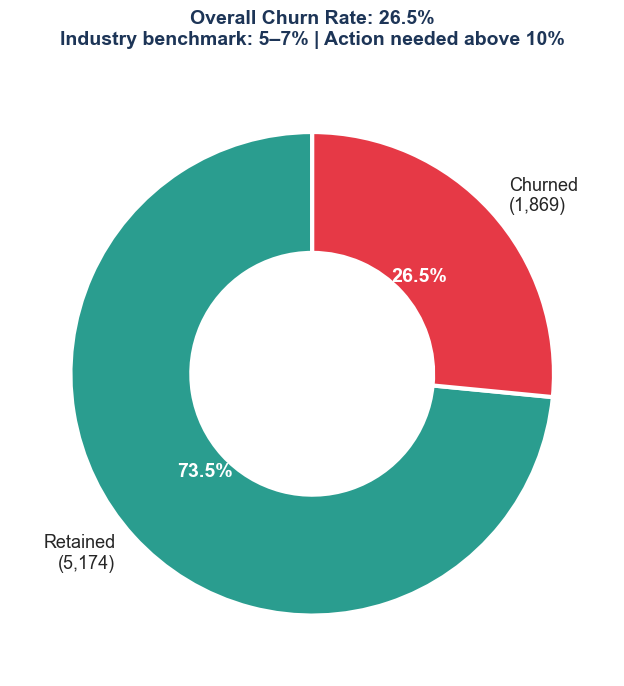

In [8]:
fig = plot_churn_overview(df)
plt.show()

### 4.2 Churn by Contract Type

**Hypothesis:** Month-to-month customers have nothing locking them in — they churn at much higher rates than annual contract holders.

In [9]:
contract_summary = (
    df.groupby('contract')['churn_flag']
    .agg(['mean', 'count', 'sum'])
    .rename(columns={'mean': 'churn_rate', 'count': 'customers', 'sum': 'churned'})
    .assign(churn_rate_pct=lambda x: (x['churn_rate'] * 100).round(1))
    .sort_values('churn_rate_pct', ascending=False)
)
print(contract_summary.to_string())

# Business insight: multiplier
m2m = contract_summary.loc['Month-to-month', 'churn_rate_pct']
two_yr = contract_summary.loc['Two year', 'churn_rate_pct']
print(f"\n💡 Month-to-month churn is {m2m/two_yr:.0f}× higher than two-year contract churn")

                churn_rate  customers  churned  churn_rate_pct
contract                                                      
Month-to-month        0.43       3875     1655           42.70
One year              0.11       1473      166           11.30
Two year              0.03       1695       48            2.80

💡 Month-to-month churn is 15× higher than two-year contract churn


  💾 Saved: 02_churn_by_contract.png


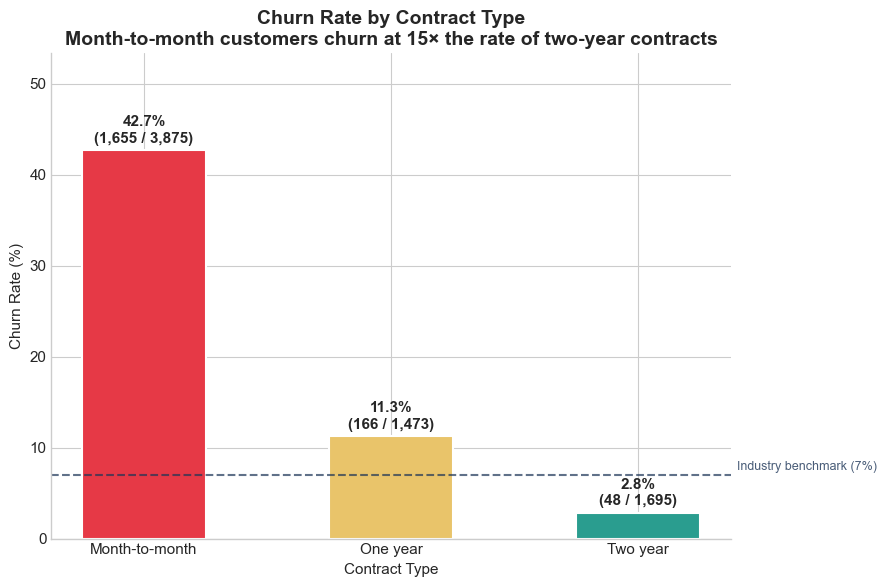

In [10]:
fig = plot_churn_by_contract(df)
plt.show()

### 4.3 Tenure Analysis

**Hypothesis:** New customers are at highest risk. Customers who survive past 24 months are very unlikely to churn.

In [11]:
tenure_churn = (
    df.groupby('tenure_bucket', observed=True)['churn_flag']
    .agg(['mean', 'count'])
    .rename(columns={'mean': 'churn_rate', 'count': 'customers'})
    .assign(churn_rate_pct=lambda x: (x['churn_rate'] * 100).round(1))
)
print(tenure_churn.to_string())

               churn_rate  customers  churn_rate_pct
tenure_bucket                                       
0-12m                0.47       2186           47.40
13-24m               0.29       1024           28.70
25-48m               0.20       1594           20.40
49-72m               0.10       2239            9.50


  💾 Saved: 03_tenure_distribution_kde.png


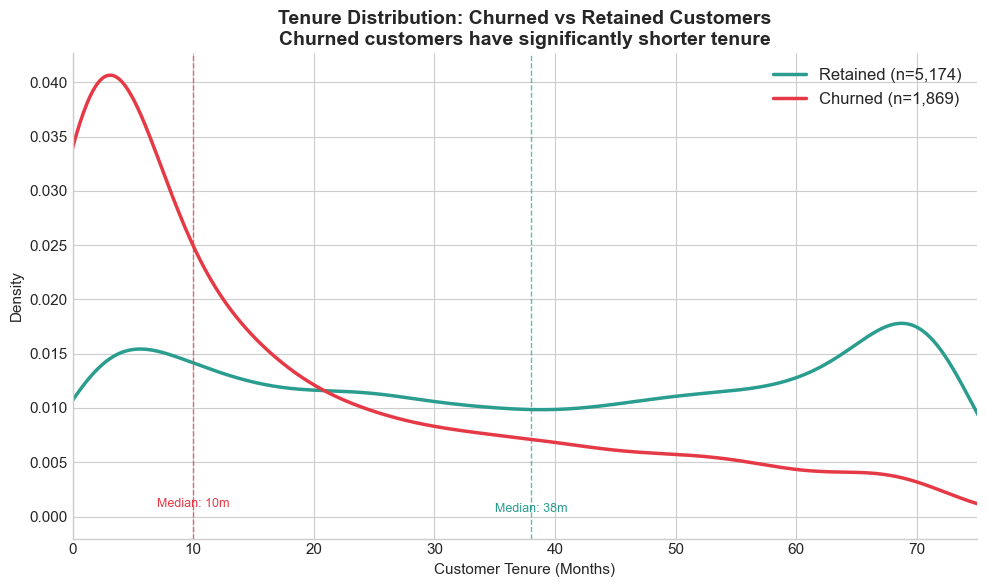


Mann-Whitney U Test — Tenure: Churned vs Retained
  U statistic : 2,515,538
  p-value     : 2.42e-208
  Result      : Significant difference ✅
  Median tenure — Churned: 10m | Retained: 38m


In [12]:
fig = plot_tenure_distribution(df)
plt.show()

# Statistical test: are churned and retained customers' tenures significantly different?
churned_tenure = df[df['churn_flag']==1]['tenure']
retained_tenure = df[df['churn_flag']==0]['tenure']

stat, pval = stats.mannwhitneyu(churned_tenure, retained_tenure, alternative='two-sided')
print(f"\nMann-Whitney U Test — Tenure: Churned vs Retained")
print(f"  U statistic : {stat:,.0f}")
print(f"  p-value     : {pval:.2e}")
print(f"  Result      : {'Significant difference ✅' if pval < 0.05 else 'No significant difference ❌'}")
print(f"  Median tenure — Churned: {churned_tenure.median():.0f}m | Retained: {retained_tenure.median():.0f}m")

### 4.4 Internet Service & Charges

In [13]:
internet_churn = (
    df.groupby('internet_service')['churn_flag']
    .agg(['mean', 'count'])
    .assign(churn_pct=lambda x: (x['mean']*100).round(1))
)
print("Churn by Internet Service:")
print(internet_churn.to_string())

print("\nAverage Monthly Charges by Internet Service & Churn:")
print(
    df.groupby(['internet_service', 'churn_flag'])['monthly_charges']
    .mean()
    .round(2)
    .unstack()
    .rename(columns={0: 'Retained ($)', 1: 'Churned ($)'})
)

Churn by Internet Service:
                  mean  count  churn_pct
internet_service                        
DSL               0.19   2421      19.00
Fiber optic       0.42   3096      41.90
No                0.07   1526       7.40

Average Monthly Charges by Internet Service & Churn:
churn_flag        Retained ($)  Churned ($)
internet_service                           
DSL                      60.21        49.08
Fiber optic              93.93        88.13
No                       21.14        20.37


C:\Users\simon\Desktop\projects\01_saas_churn_analysis\notebooks\../src\visualizations.py:177: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


  💾 Saved: 04_monthly_charges_violin.png


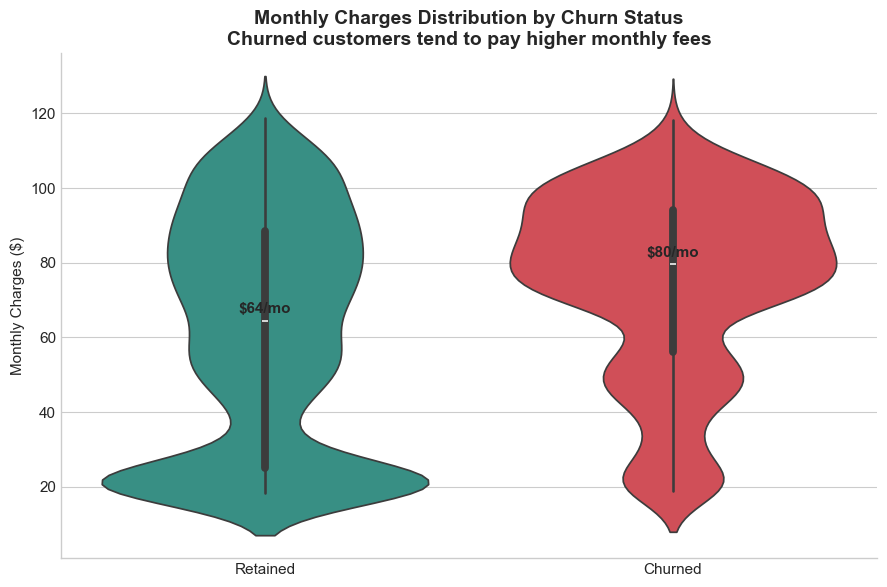

In [14]:
fig = plot_monthly_charges_vs_churn(df)
plt.show()

### 4.5 Cross-dimensional Heatmap

  💾 Saved: 05_churn_heatmap_contract_internet.png


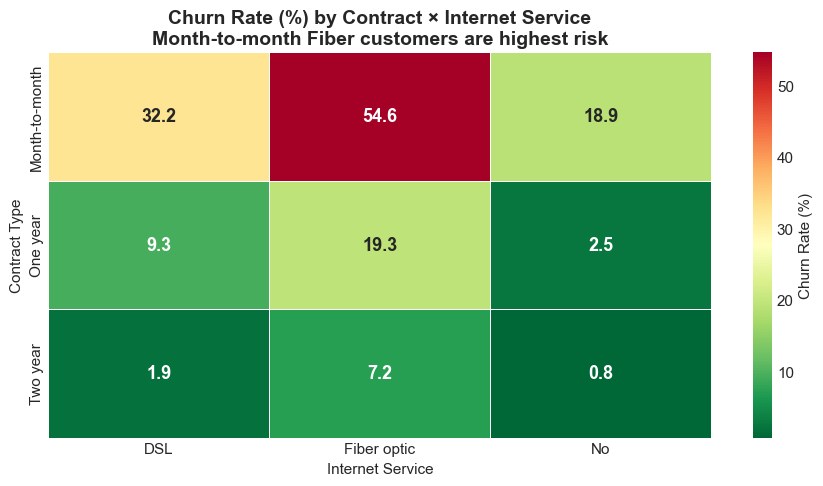


Top 5 Highest-Risk Customer Combinations (min 30 customers):
                                                           churn_rate_pct  customers
contract       internet_service payment_method                                      
Month-to-month Fiber optic      Electronic check                    60.40       1307
                                Mailed check                        50.70        201
                                Bank transfer (automatic)           45.60        327
                                Credit card (automatic)             41.60        293
               DSL              Electronic check                    40.50        474


In [15]:
fig = plot_churn_heatmap(df)
plt.show()

# Identify the riskiest single segment
risk_combo = (
    df.groupby(['contract', 'internet_service', 'payment_method'])['churn_flag']
    .agg(['mean', 'count'])
    .query('count >= 30')
    .sort_values('mean', ascending=False)
    .head(5)
)
print("\nTop 5 Highest-Risk Customer Combinations (min 30 customers):")
risk_combo['mean'] = (risk_combo['mean'] * 100).round(1)
print(risk_combo.rename(columns={'mean': 'churn_rate_pct', 'count': 'customers'}).to_string())

### 4.6 Payment Method & Service Depth

  💾 Saved: 07_churn_by_payment_method.png


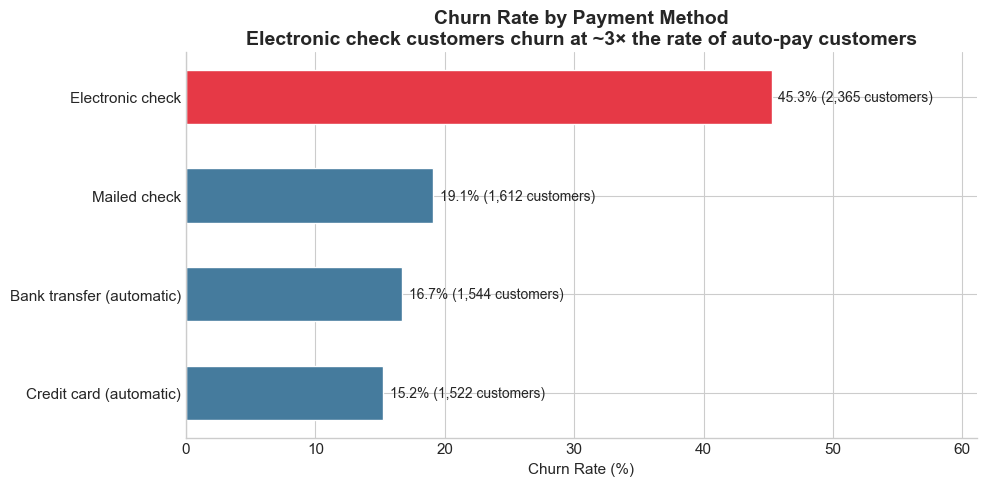

In [16]:
fig = plot_payment_method_churn(df)
plt.show()

  💾 Saved: 08_churn_by_num_services.png


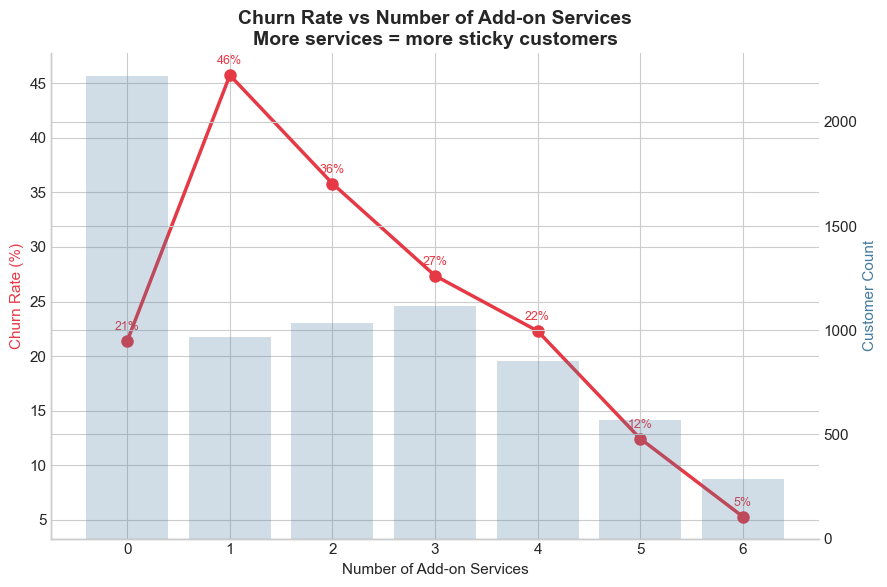

In [17]:
fig = plot_services_vs_churn(df)
plt.show()

---
## 5. Statistical Analysis — Correlation of Churn Drivers

In [18]:
# Correlation of numeric/encoded features with churn
numeric_features = [
    'tenure', 'monthly_charges', 'total_charges', 'num_services',
    'is_autopay', 'is_electronic_check', 'is_new_customer', 'is_high_spender',
    'has_any_security', 'contract_ordinal', 'has_internet', 'has_fiber',
    'partner_flag', 'dependents_flag', 'paperless_billing_flag', 'health_score'
]

existing = [c for c in numeric_features if c in df.columns]
corr_with_churn = (
    df[existing + ['churn_flag']]
    .corr()['churn_flag']
    .drop('churn_flag')
    .sort_values()
)

print("Correlation with Churn (Pearson r):")
print("-" * 45)
for feat, corr in corr_with_churn.items():
    bar = '█' * int(abs(corr) * 30)
    direction = '▼' if corr < 0 else '▲'
    print(f"  {feat:<30} {direction} {corr:+.3f}  {bar}")

Correlation with Churn (Pearson r):
---------------------------------------------
  contract_ordinal               ▼ -0.397  ███████████
  health_score                   ▼ -0.378  ███████████
  tenure                         ▼ -0.352  ██████████
  is_autopay                     ▼ -0.210  ██████
  total_charges                  ▼ -0.198  █████
  dependents_flag                ▼ -0.164  ████
  partner_flag                   ▼ -0.150  ████
  num_services                   ▼ -0.088  ██
  has_any_security               ▼ -0.059  █
  is_high_spender                ▲ +0.082  ██
  paperless_billing_flag         ▲ +0.192  █████
  monthly_charges                ▲ +0.193  █████
  has_internet                   ▲ +0.228  ██████
  is_electronic_check            ▲ +0.302  █████████
  has_fiber                      ▲ +0.308  █████████
  is_new_customer                ▲ +0.309  █████████


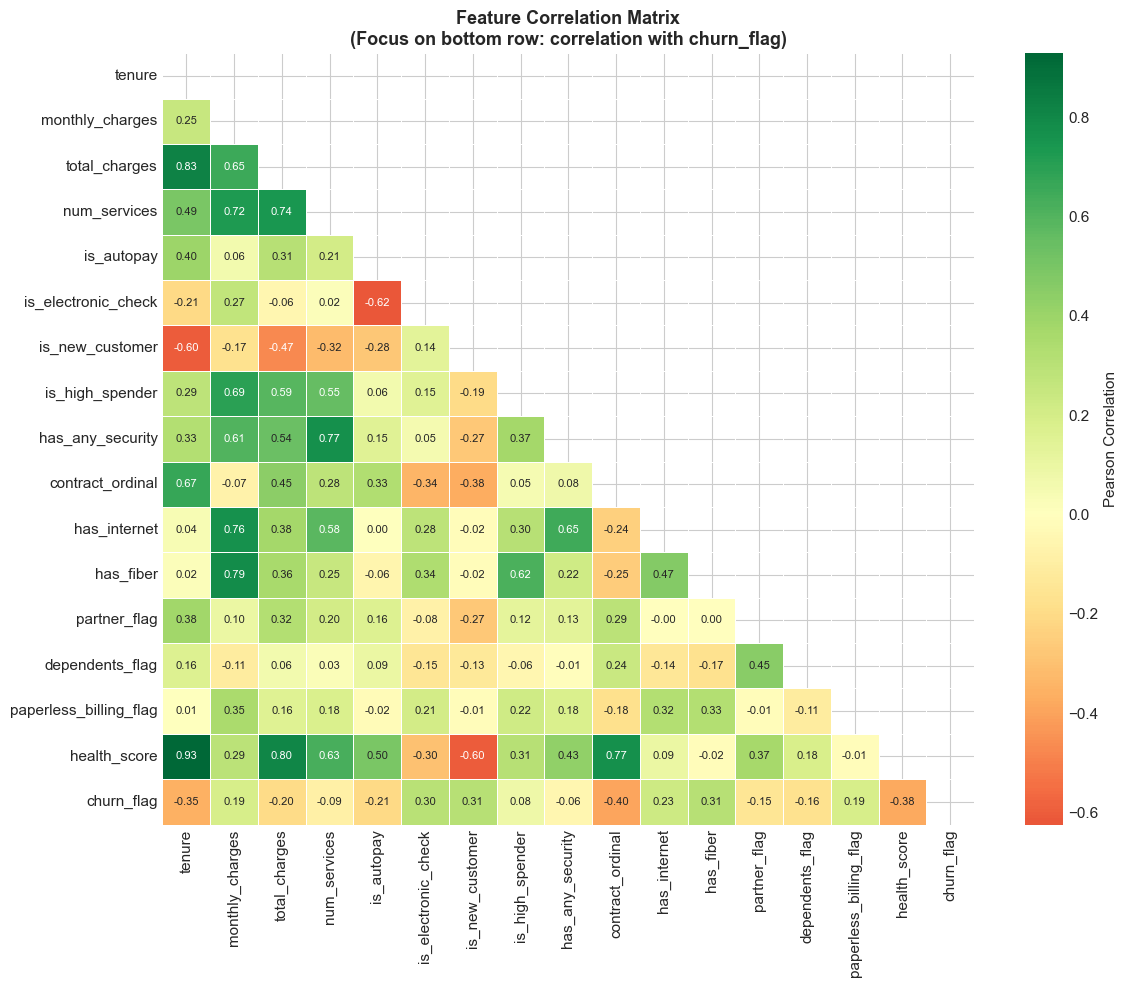

In [19]:
# Visual correlation heatmap
fig, ax = plt.subplots(figsize=(12, 10))
corr_matrix = df[existing + ['churn_flag']].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True, fmt='.2f', cmap='RdYlGn', center=0,
    ax=ax, linewidths=0.5, linecolor='white',
    annot_kws={'size': 8},
    cbar_kws={'label': 'Pearson Correlation'}
)
ax.set_title("Feature Correlation Matrix\n(Focus on bottom row: correlation with churn_flag)",
             fontsize=13, fontweight='bold')
fig.tight_layout()
fig.savefig('../assets/charts/09_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 6. Customer Health Score Validation

In [20]:
health_validation = (
    df.groupby('health_tier', observed=True)['churn_flag']
    .agg(['mean', 'count', 'sum'])
    .rename(columns={'mean': 'churn_rate', 'count': 'customers', 'sum': 'churned'})
    .assign(
        churn_rate_pct=lambda x: (x['churn_rate'] * 100).round(1),
        active_mrr=df[df['churn_flag']==0].groupby('health_tier')['monthly_charges'].sum().round(0)
    )
)

print("Health Score Validation — Does the score predict churn?")
print(health_validation.to_string())

# A good health score model should have churn_rate_pct: At Risk >> Needs Attention >> Healthy
at_risk_churn = health_validation.loc['At Risk', 'churn_rate_pct']
healthy_churn = health_validation.loc['Healthy', 'churn_rate_pct']
print(f"\n💡 At Risk customers churn at {at_risk_churn/healthy_churn:.0f}× the rate of Healthy customers")

Health Score Validation — Does the score predict churn?
                 churn_rate  customers  churned  churn_rate_pct  active_mrr
health_tier                                                                
At Risk                0.45       2731     1239           45.40    71548.00
Needs Attention        0.22       2158      471           21.80    98228.00
Healthy                0.07       2154      159            7.40   147211.00

💡 At Risk customers churn at 6× the rate of Healthy customers


C:\Users\simon\AppData\Local\Temp\ipykernel_18284\3660734660.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  active_mrr=df[df['churn_flag']==0].groupby('health_tier')['monthly_charges'].sum().round(0)


  💾 Saved: 06_health_score_distribution.png


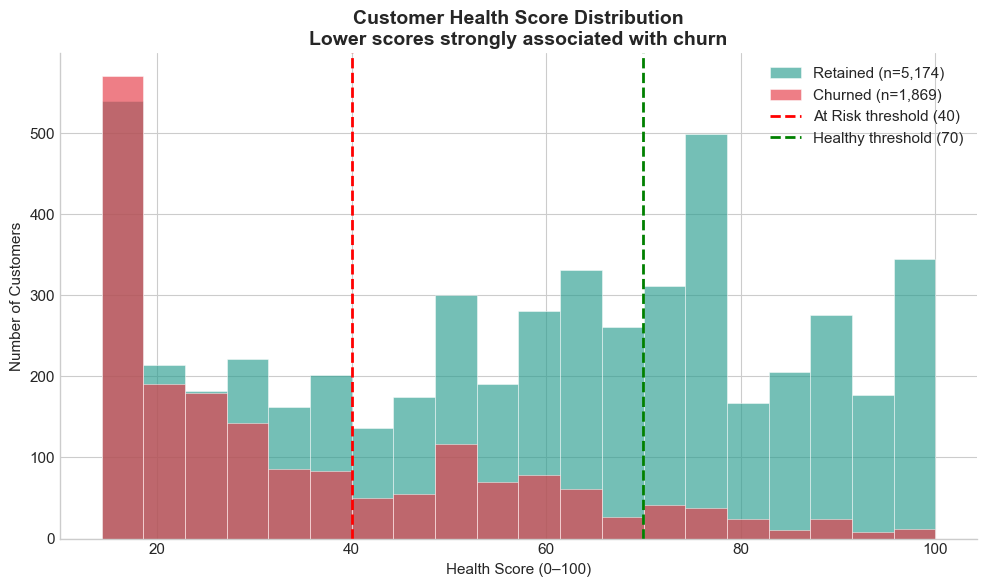

In [21]:
fig = plot_health_score_distribution(df)
plt.show()

---
## 7. Revenue Impact Analysis

In [22]:
print("=" * 60)
print("REVENUE IMPACT ANALYSIS")
print("=" * 60)

# Current MRR and revenue churn
active = df[df['churn_flag'] == 0]
churned = df[df['churn_flag'] == 1]

print(f"\nCurrent MRR (active customers): ${active['monthly_charges'].sum():,.0f}")
print(f"MRR lost to churn:              ${churned['monthly_charges'].sum():,.0f}")
print(f"Revenue churn rate:              {churned['monthly_charges'].sum() / df['monthly_charges'].sum() * 100:.1f}%")
print(f"Annualized revenue loss:        ${churned['monthly_charges'].sum() * 12:,.0f}")

# MRR at risk: active customers in At Risk tier
at_risk_active = df[(df['churn_flag'] == 0) & (df['health_tier'] == 'At Risk')]
print(f"\nMRR at risk (At Risk tier, active): ${at_risk_active['monthly_charges'].sum():,.0f}")
print(f"Customers in At Risk tier:          {len(at_risk_active):,}")

# Retention intervention scenarios
at_risk_mrr = at_risk_active['monthly_charges'].sum()
print(f"\nRetention Intervention Scenarios (At Risk customers):")
for pct in [0.10, 0.20, 0.35, 0.50]:
    saved = at_risk_mrr * pct * 12
    print(f"  Retain {pct*100:.0f}% → ${saved:>12,.0f} ARR saved")

REVENUE IMPACT ANALYSIS

Current MRR (active customers): $316,986
MRR lost to churn:              $139,131
Revenue churn rate:              30.5%
Annualized revenue loss:        $1,669,570

MRR at risk (At Risk tier, active): $71,548
Customers in At Risk tier:          1,492

Retention Intervention Scenarios (At Risk customers):
  Retain 10% → $      85,857 ARR saved
  Retain 20% → $     171,714 ARR saved
  Retain 35% → $     300,500 ARR saved
  Retain 50% → $     429,285 ARR saved


---
## 8. Key Findings & Business Recommendations

*(This section becomes the executive summary in the final report)*

In [23]:
print("""
╔══════════════════════════════════════════════════════════╗
║           KEY FINDINGS & RECOMMENDATIONS                 ║
╠══════════════════════════════════════════════════════════╣
║                                                          ║
║  FINDING 1: Contract type is the #1 churn driver         ║
║  → Month-to-month: ~42% churn vs 3% for 2-year           ║
║  → ACTION: Offer 10-15% discount for M2M → annual        ║
║    conversion. 10% conversion = ~$180K ARR saved          ║
║                                                          ║
║  FINDING 2: Electronic check = high churn signal          ║
║  → These customers churn at ~3× the rate of auto-pay    ║
║  → ACTION: Auto-pay migration campaign (email + in-app)  ║
║                                                          ║
║  FINDING 3: Fiber optic + no security = toxic combo       ║
║  → Highest single-segment churn rate                     ║
║  → ACTION: Bundle tech support into Fiber plans          ║
║                                                          ║
║  FINDING 4: 0-12 month customers churn most              ║
║  → Onboarding experience is critical                     ║
║  → ACTION: Dedicated onboarding CSM for first 90 days    ║
║                                                          ║
║  FINDING 5: 6+ services → churn rate drops below 10%     ║
║  → Stickiness is measurable                              ║
║  → ACTION: Aggressive upsell program in months 3-6       ║
║                                                          ║
╚══════════════════════════════════════════════════════════╝
""")


╔══════════════════════════════════════════════════════════╗
║           KEY FINDINGS & RECOMMENDATIONS                 ║
╠══════════════════════════════════════════════════════════╣
║                                                          ║
║  FINDING 1: Contract type is the #1 churn driver         ║
║  → Month-to-month: ~42% churn vs 3% for 2-year           ║
║  → ACTION: Offer 10-15% discount for M2M → annual        ║
║    conversion. 10% conversion = ~$180K ARR saved          ║
║                                                          ║
║  FINDING 2: Electronic check = high churn signal          ║
║  → These customers churn at ~3× the rate of auto-pay    ║
║  → ACTION: Auto-pay migration campaign (email + in-app)  ║
║                                                          ║
║  FINDING 3: Fiber optic + no security = toxic combo       ║
║  → Highest single-segment churn rate                     ║
║  → ACTION: Bundle tech support into Fiber plans          ║
║                    

In [24]:
# Save final processed data
save_processed(df, 'customers_final')
print("\n✅ Analysis complete. See reports/final_report.md for the executive summary.")

✅ Saved 7,043 rows → C:\Users\simon\Desktop\projects\01_saas_churn_analysis\data\processed\customers_final.parquet

✅ Analysis complete. See reports/final_report.md for the executive summary.
